**PART A**

DATA PREPROCESSING

In [796]:
import pandas as pd
data=pd.read_csv('student_survey.csv')
data.head()


,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


In [797]:
data.columns

Index(['Timestamp', 'Registration Number', 'Email',
       'Job role that you are interested in',
       'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
       'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
       'What is the median salary of students placed through campus (In LPA..respond as a number)',
       'Which is the highest paying company that recruits from campus?',
       'Rate your contribution towards extra curricular activities',
       'Rate your technical competencies',
       'What are your package expectations (LPA)',
       'Your CIA % of last semester', 'Your GPA of last semester',
       'Your maximum attendance % till last semester',
       'Internships Interests'],
      dtype='object')

In [798]:
data.shape

(50, 15)

In [799]:
print(data.dtypes)

Timestamp                                                                                      object
Registration Number                                                                             int64
Email                                                                                          object
Job role that you are interested in                                                            object
What is the minimum salary of students placed through campus (In LPA..respond as a number)     object
What is the maximum salary of students placed through campus (In LPA..respond as a number)     object
What is the median salary of students placed through campus (In LPA..respond as a number)      object
Which is the highest paying company that recruits from campus?                                 object
Rate your contribution towards extra curricular activities                                    float64
Rate your technical competencies                                                  

In [800]:
data=data.drop(columns=['Timestamp','Email','Registration Number' ], axis=1)

In [801]:
data.rename(columns={
    "Job role that you are interested in": "Job_Role",

    "What is the minimum salary of students placed through campus (In LPA..respond as a number)": "Min_Salary_LPA",

    "What is the maximum salary of students placed through campus (In LPA..respond as a number)": "Max_Salary_LPA",

    "What is the median salary of students placed through campus (In LPA..respond as a number)": "Median_Salary_LPA",

    "Which is the highest paying company that recruits from campus?": "Highest_Paying_Company",

    "Rate your contribution towards extra curricular activities": "Extra_Curricular_Rating",

    "Rate your technical competencies": "Technical_Competency_Rating",

    "What are your package expectations (LPA)": "Expected_Package_LPA",

    "Your CIA % of last semester": "CIA_Percentage",

    "Your GPA of last semester": "GPA",

    "Your maximum attendance % till last semester": "Attendance_Percentage",

    "Internships Interests": "Internship_Interests"
}, inplace=True)


print(data.columns)

Index(['Job_Role', 'Min_Salary_LPA', 'Max_Salary_LPA', 'Median_Salary_LPA',
       'Highest_Paying_Company', 'Extra_Curricular_Rating',
       'Technical_Competency_Rating', 'Expected_Package_LPA', 'CIA_Percentage',
       'GPA', 'Attendance_Percentage', 'Internship_Interests'],
      dtype='object')


renamed the columns for convinient pre processing

In [802]:
data=data.drop(columns=['Job_Role','Highest_Paying_Company','Internship_Interests' ], axis=1)

In [803]:
data.shape


(50, 9)

In [804]:
null_values=data.isnull().sum()
null_values

,0
Min_Salary_LPA,0
Max_Salary_LPA,0
Median_Salary_LPA,0
Extra_Curricular_Rating,1
Technical_Competency_Rating,1
Expected_Package_LPA,1
CIA_Percentage,0
GPA,0
Attendance_Percentage,0


In [805]:
data.dropna(inplace=True)

the dataset has only one row with null values so it had been dropped

In [806]:
null_values=data.isnull().sum()
null_values

,0
Min_Salary_LPA,0
Max_Salary_LPA,0
Median_Salary_LPA,0
Extra_Curricular_Rating,0
Technical_Competency_Rating,0
Expected_Package_LPA,0
CIA_Percentage,0
GPA,0
Attendance_Percentage,0


In [807]:
print('After dropping null values')
data.shape

After dropping null values


(49, 9)

In [808]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Min_Salary_LPA               49 non-null     object 
 1   Max_Salary_LPA               49 non-null     object 
 2   Median_Salary_LPA            49 non-null     object 
 3   Extra_Curricular_Rating      49 non-null     float64
 4   Technical_Competency_Rating  49 non-null     float64
 5   Expected_Package_LPA         49 non-null     object 
 6   CIA_Percentage               49 non-null     object 
 7   GPA                          49 non-null     float64
 8   Attendance_Percentage        49 non-null     object 
dtypes: float64(3), object(6)
memory usage: 3.8+ KB


In [809]:
import pandas as pd
import numpy as np
import re

def clean_value(x):

    if pd.isna(x):
        return np.nan

    x = str(x).lower()


    x = x.replace('lpa', '').replace('%', '').replace('+', '').replace('l', '')

    if '-' in x:
        nums = re.findall(r'\d+\.?\d*', x)
        return np.mean([float(i) for i in nums])

    nums = re.findall(r'\d+\.?\d*', x)

    if not nums:
        return np.nan

    num = float(nums[0])


    if num > 100000:
        num /= 100000

    return num

this function converts the text in lower values and cleans the numeric data which contains lpa , % and +

In [810]:
for col in data.columns:
    data[col] = data[col].apply(clean_value)

In [811]:
data = data[(data['GPA'] <= 4) & (data['CIA_Percentage'] >= 20)]

In [812]:
data[(data['GPA'] > 4) | (data['CIA_Percentage'] < 20)]
data.shape

(48, 9)

In [813]:
print("Duplicates:", data.duplicated().sum())

Duplicates: 0


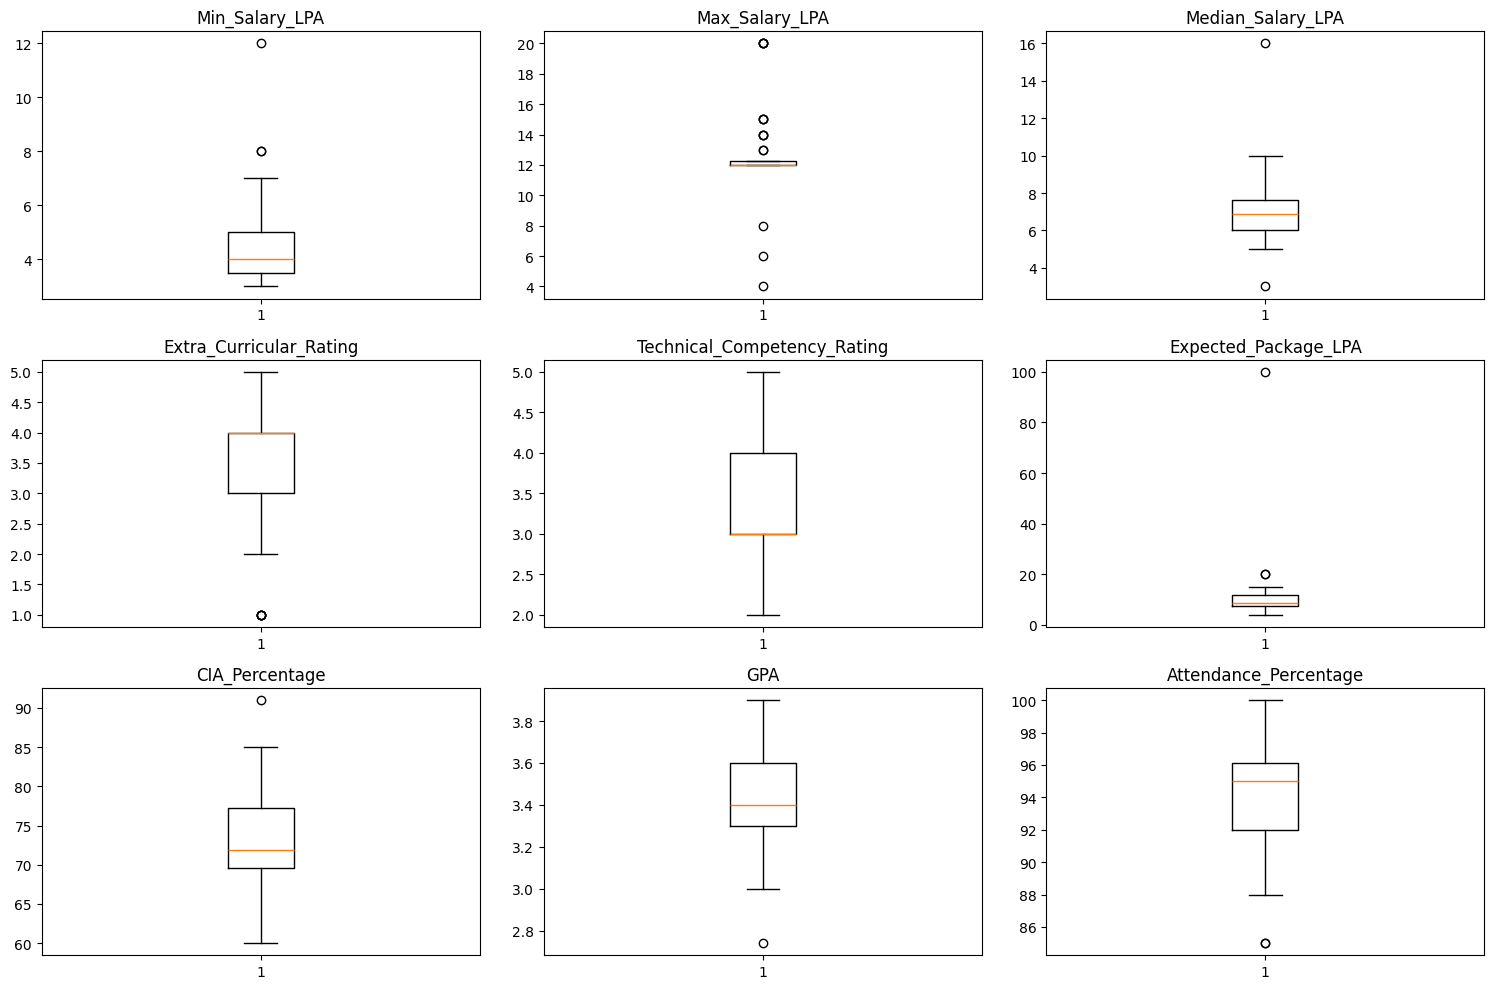

In [814]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

axes = axes.flatten()

for i, col in enumerate(data.columns):
    axes[i].boxplot(data[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Experiment 1: CIA Percentage → GPA**

In [815]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [816]:
X1 = data[['CIA_Percentage']]
y1 = data['GPA']

In [817]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42
)

In [818]:
model1 = LinearRegression()

model1.fit(X1_train, y1_train)

LinearRegression()

In [819]:
print("Experiment 1")

print("Slope:", model1.coef_[0])

print("Intercept:", model1.intercept_)

Experiment 1
Slope: 0.01752685626778003
Intercept: 2.133321195068091


In [820]:
y1_pred = model1.predict(X1_test)

print(y1_pred)

[3.48288913 3.35634523 3.37772799 3.44783542 3.36020113 3.27256685
 3.50041598 3.23751314 3.36020113 3.36020113]


In [821]:
m = model1.coef_[0]
b = model1.intercept_

print(f"GPA = {m:.4f} * CIA_Percentage + {b:.4f}")

GPA = 0.0175 * CIA_Percentage + 2.1333


In [822]:
import pandas as pd

comparison1 = pd.DataFrame({
    'Actual_GPA': y1_test,
    'Predicted_GPA': y1_pred
})

print(comparison1)

    Actual_GPA  Predicted_GPA
29        3.30       3.482889
42        3.30       3.356345
28        3.33       3.377728
45        3.66       3.447835
26        3.40       3.360201
39        3.30       3.272567
12        3.32       3.500416
21        3.40       3.237513
4         3.54       3.360201
27        3.00       3.360201


In [823]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y1_pred = model1.predict(X1_test)


mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y1_test, y1_pred)

print("Experiment 1: CIA Percentage -> GPA")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Experiment 1: CIA Percentage -> GPA
MAE : 0.14492617857800286
MSE : 0.030727591293070965
RMSE: 0.1752928729100843
R² Score: -0.14548336600450873


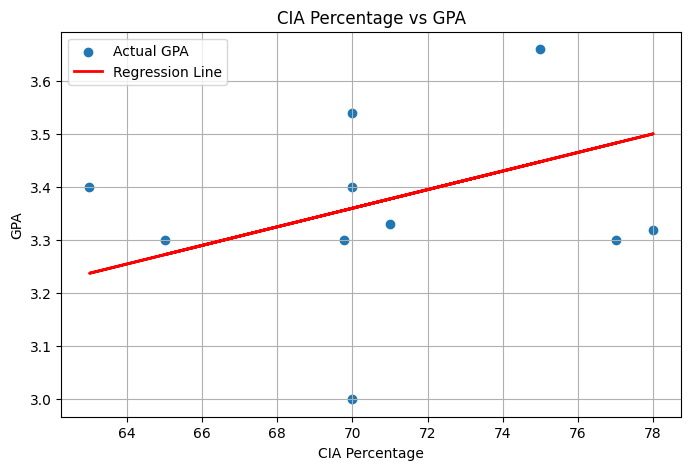

In [824]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(X1_test, y1_test, label='Actual GPA')

plt.plot(
    X1_test,
    y1_pred,
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("CIA Percentage vs GPA")
plt.legend()
plt.grid(True)

plt.show()

The regression line has a positive slope

GPA tends to increase slightly as CIA Percentage increases

 the data points are highly scattered

R² = -0.1455, indicating a very weak linear relationship

**Experiment 2: Attendance Percentage → GPA**

In [825]:
X2 = data[['Attendance_Percentage']]
y2 = data['GPA']

In [826]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.3,
    random_state=42
)

In [827]:
model2 = LinearRegression()

model2.fit(X2_train, y2_train)

LinearRegression()

In [828]:
print("Experiment 2")

print("Slope:", model2.coef_[0])

print("Intercept:", model2.intercept_)

Experiment 2
Slope: 0.02972024442651177
Intercept: 0.5974371143953765


In [829]:
y2_pred = model2.predict(X2_test)

print(y2_pred)

[3.27225911 3.3316996  3.53974131 3.42086033 3.45058058 3.24253887
 3.42086033 3.27225911 3.36141985 3.36141985 3.27225911 3.3316996
 3.39114009 3.45058058 3.21281862]


In [830]:
m = model2.coef_[0]
b = model2.intercept_

print(f"GPA = {m:.4f} * Attendance_Percentage + {b:.4f}")

GPA = 0.0297 * Attendance_Percentage + 0.5974


In [831]:
comparison2 = pd.DataFrame({
    'Actual_GPA': y2_test,
    'Predicted_GPA': y2_pred
})

print(comparison2)

    Actual_GPA  Predicted_GPA
29        3.30       3.272259
42        3.30       3.331700
28        3.33       3.539741
45        3.66       3.420860
26        3.40       3.450581
39        3.30       3.242539
12        3.32       3.420860
21        3.40       3.272259
4         3.54       3.361420
27        3.00       3.361420
8         3.60       3.272259
3         3.60       3.331700
6         3.40       3.391140
41        3.54       3.450581
35        3.40       3.212819


In [832]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y2_pred = model2.predict(X2_test)

mae = mean_absolute_error(y2_test, y2_pred)
mse = mean_squared_error(y2_test, y2_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y2_test, y2_pred)

print("Experiment 2: Attendance Percentage -> GPA")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Experiment 2: Attendance Percentage -> GPA
MAE : 0.151097759433661
MSE : 0.034688660336562
RMSE: 0.18624892036348023
R² Score: -0.3425789685427534


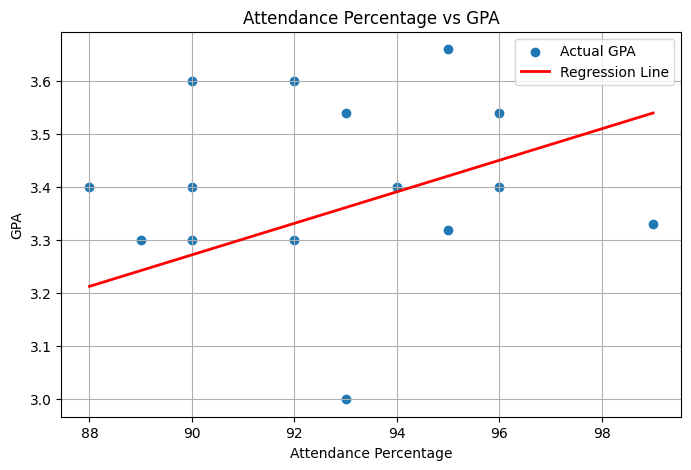

In [833]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    'Attendance': X2_test['Attendance_Percentage'],
    'Actual_GPA': y2_test,
    'Predicted_GPA': y2_pred
})

plot_df = plot_df.sort_values('Attendance')

plt.figure(figsize=(8,5))

plt.scatter(
    plot_df['Attendance'],
    plot_df['Actual_GPA'],
    label='Actual GPA'
)

plt.plot(
    plot_df['Attendance'],
    plot_df['Predicted_GPA'],
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Attendance Percentage vs GPA")
plt.legend()
plt.grid(True)

plt.show()

The regression line also has a positive slope

Students with higher attendance tend to have slightly higher GPAs

The fit is marginally better than Experiment 1

R² = -0.1053, which is still a poor fit

**Part C: Manual Computation using Ordinary Least Squares (OLS)**

**Experiment 1**

In [834]:
import numpy as np
import pandas as pd

x = X1_train['CIA_Percentage'].values
y = y1_train.values


x_mean = np.mean(x)
y_mean = np.mean(y)

m1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
b1 = y_mean - m1 * x_mean

print(" EXPERIMENT 1 ")
print("CIA Percentage -> GPA")
print("Manual Slope:", m1)
print("Manual Intercept:", b1)

print(f"Regression Equation:")
print(f"GPA = {m1:.6f} * CIA_Percentage + {b1:.6f}")


manual_pred1 = m1 * X1_test['CIA_Percentage'].values + b1

sklearn_pred1 = model1.predict(X1_test)


comparison1 = pd.DataFrame({
    'Actual_GPA': y1_test.values,
    'Sklearn_Prediction': sklearn_pred1,
    'Manual_Prediction': manual_pred1
})

comparison1['Difference'] = (
    comparison1['Sklearn_Prediction']
    - comparison1['Manual_Prediction']
)

print("\nComparison Table")
print(comparison1)

print("\nMaximum Difference:",
      comparison1['Difference'].abs().max())



 EXPERIMENT 1 
CIA Percentage -> GPA
Manual Slope: 0.01752685626778003
Manual Intercept: 2.133321195068091
Regression Equation:
GPA = 0.017527 * CIA_Percentage + 2.133321

Comparison Table
   Actual_GPA  Sklearn_Prediction  Manual_Prediction  Difference
0        3.30            3.482889           3.482889         0.0
1        3.30            3.356345           3.356345         0.0
2        3.33            3.377728           3.377728         0.0
3        3.66            3.447835           3.447835         0.0
4        3.40            3.360201           3.360201         0.0
5        3.30            3.272567           3.272567         0.0
6        3.32            3.500416           3.500416         0.0
7        3.40            3.237513           3.237513         0.0
8        3.54            3.360201           3.360201         0.0
9        3.00            3.360201           3.360201         0.0

Maximum Difference: 0.0


The manual OLS implementation and Scikit-Learn's Linear Regression model generated the same slope, intercept, and predictions
Therefore the manual computation has been verified as correct

**Experiment 2**

In [835]:



x = X2_train['Attendance_Percentage'].values
y = y2_train.values

x_mean = np.mean(x)
y_mean = np.mean(y)

m2 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
b2 = y_mean - m2 * x_mean

print("\nEXPERIMENT 2")
print("Attendance Percentage -> GPA")
print("Manual Slope:", m2)
print("Manual Intercept:", b2)

print(f"Regression Equation:")
print(f"GPA = {m2:.6f} * Attendance_Percentage + {b2:.6f}")


manual_pred2 = m2 * X2_test['Attendance_Percentage'].values + b2


sklearn_pred2 = model2.predict(X2_test)

comparison2 = pd.DataFrame({
    'Actual_GPA': y2_test.values,
    'Sklearn_Prediction': sklearn_pred2,
    'Manual_Prediction': manual_pred2
})

comparison2['Difference'] = (
    comparison2['Sklearn_Prediction']
    - comparison2['Manual_Prediction']
)

print("\nComparison Table")
print(comparison2)

print("\nMaximum Difference:",
      comparison2['Difference'].abs().max())


EXPERIMENT 2
Attendance Percentage -> GPA
Manual Slope: 0.029720244426511767
Manual Intercept: 0.5974371143953765
Regression Equation:
GPA = 0.029720 * Attendance_Percentage + 0.597437

Comparison Table
    Actual_GPA  Sklearn_Prediction  Manual_Prediction    Difference
0         3.30            3.272259           3.272259  4.440892e-16
1         3.30            3.331700           3.331700  4.440892e-16
2         3.33            3.539741           3.539741  4.440892e-16
3         3.66            3.420860           3.420860  0.000000e+00
4         3.40            3.450581           3.450581  0.000000e+00
5         3.30            3.242539           3.242539  4.440892e-16
6         3.32            3.420860           3.420860  0.000000e+00
7         3.40            3.272259           3.272259  4.440892e-16
8         3.54            3.361420           3.361420  4.440892e-16
9         3.00            3.361420           3.361420  4.440892e-16
10        3.60            3.272259           3.2

The manually computed OLS regression model produced the same slope intercept and predictions as the Scikit-Learn LinearRegression model The observed differences were on the order of 10^16
 which are due to floating-point precision limitations and can be considered negligible Therefore, both methods produce effectively identical results

**Saving Paramenters in Pickel File**

In [836]:
import pickle

slope = model1.coef_[0]
intercept = model1.intercept_

weights = {
    'slope': slope,
    'intercept': intercept
}


with open('linear_regression_weights.pkl', 'wb') as file:
    pickle.dump(weights, file)



In [837]:
import pickle

with open('linear_regression_weights.pkl', 'rb') as file:
    loaded_weights = pickle.load(file)

print("Loaded Parameters:")
print("Slope:", loaded_weights['slope'])
print("Intercept:", loaded_weights['intercept'])

Loaded Parameters:
Slope: 0.01752685626778003
Intercept: 2.133321195068091


In [838]:

cia_percentage = 75


m = loaded_weights['slope']
b = loaded_weights['intercept']


predicted_gpa = m * cia_percentage + b

print("Predicted GPA:", predicted_gpa)

Predicted GPA: 3.4478354151515935


In [839]:
import pickle

weights = {
    'Experiment_1': {
        'slope': model1.coef_[0],
        'intercept': model1.intercept_
    },
    'Experiment_2': {
        'slope': model2.coef_[0],
        'intercept': model2.intercept_
    }
}

with open('linear_regression_weights.pkl', 'wb') as file:
    pickle.dump(weights, file)



In [840]:
import pickle

with open('linear_regression_weights.pkl', 'rb') as file:
    weights = pickle.load(file)


cia = 75
gpa_pred1 = (
    weights['Experiment_1']['slope'] * cia
    + weights['Experiment_1']['intercept']
)

print("Predicted GPA using CIA:", gpa_pred1)


attendance = 95
gpa_pred2 = (
    weights['Experiment_2']['slope'] * attendance
    + weights['Experiment_2']['intercept']
)

print("Predicted GPA using Attendance:", gpa_pred2)

Predicted GPA using CIA: 3.4478354151515935
Predicted GPA using Attendance: 3.4208603349139945


Pickle is a Python module used to save objects into a file so they can be reused later without retraining the model

In this experiment the slope and intercept learned by the Linear Regression model were stored in a file named linear_regression_weights.pkl. The file was then loaded back, and the saved parameters were used to make predictions using the regression equation

**Overall Interpretation**

This experiment focused on applying Simple Linear Regression to study the relationship between student academic performance indicators and GPA

The dataset was first preprocessed by handling missing values, removing duplicates, converting columns to numerical format, and cleaning inconsistent entries. Two regression experiments were then performed

CIA Percentage → GPA
Attendance Percentage → GPA

For each experiment  the dataset was split into training and testing sets  and a Linear Regression model was trained using Scikit-Learn  slope, intercept, predictions, and performance metrics were obtained the regression equations were also computed manually using the Ordinary Least Squares (OLS) method

The manually calculated slope and intercept matched the values produced by Scikit-Learn  and the predictions from both methods were identical, confirming the correctness of the manual OLS implementation the model parameters slope and intercept were saved and loaded using Pickling method